# Aussagekraft der Ratio über Stocks und Volumen

In diesem Notebook soll die Raito Advancing/Declining Volume sowie Advancing/Declining Stocks untersucht werden.

1. Bibliotheken laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

2. Daten laden

In [2]:
boerse = 'NYSE'

In [3]:
advancing_stocks = pd.read_csv(f"{boerse} Advancing Stocks.csv", parse_dates=["time"])
advancing_stocks = advancing_stocks[advancing_stocks["time"] >= pd.Timestamp("2006-12-31")]
advancing_stocks.info()
advancing_volume = pd.read_csv(f"{boerse} Advancing Volume.csv", parse_dates=["time"])
advancing_volume = advancing_volume[advancing_volume["time"] >= pd.Timestamp("2006-12-31")]
advancing_volume.info()
declining_stocks = pd.read_csv(f"{boerse} Declining Stocks.csv", parse_dates=["time"])
declining_stocks = declining_stocks[declining_stocks["time"] >= pd.Timestamp("2006-12-31")]
declining_stocks.info()
declining_volume = pd.read_csv(f"{boerse} Declining Volume.csv", parse_dates=["time"])
declining_volume = declining_volume[declining_volume["time"] >= pd.Timestamp("2006-12-31")]
declining_volume.info()

# NASDAQ Composite, um die Ratio dann mit dem Markt zu vergleichen
raw = yf.download("^IXIC", start="2007-01-01", interval="1d", auto_adjust=True, progress=False, multi_level_index=False)

<class 'pandas.DataFrame'>
RangeIndex: 4745 entries, 0 to 4744
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    4745 non-null   datetime64[us]
 1   open    4745 non-null   int64         
 2   high    4745 non-null   int64         
 3   low     4745 non-null   int64         
 4   close   4745 non-null   int64         
 5   EMA     4546 non-null   float64       
 6   EMA.1   4726 non-null   float64       
 7   EMA.2   4696 non-null   float64       
 8   EMA.3   4646 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(4)
memory usage: 333.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 4738 entries, 0 to 4737
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    4738 non-null   datetime64[us]
 1   open    4738 non-null   float64       
 2   high    4738 non-null   float64       
 3   low     4738 non-null   float6

In [4]:
df = advancing_stocks[['time', 'close']]
df = df.rename(columns={'close' : 'advancing_stocks'})

df["time"] = pd.to_datetime(df["time"])
advancing_volume["time"] = pd.to_datetime(advancing_volume["time"])
declining_stocks["time"] = pd.to_datetime(declining_stocks["time"])
declining_volume["time"] = pd.to_datetime(declining_volume["time"])

df = df.set_index("time")

df = (df
    .join(advancing_volume.set_index("time")[["close"]].rename(columns= {"close": "advancing_volume"}),how = "left")
    .join(declining_stocks.set_index("time")[["close"]].rename(columns= {"close": "declining_stocks"}),how = "left")
    .join(declining_volume.set_index("time")[["close"]].rename(columns= {"close": "declining_volume"}),how = "left")
)
print(df.tail())

            advancing_stocks  advancing_volume  declining_stocks  \
time                                                               
2026-08-04              1225           4044.96             626.0   
2026-08-05               801           2466.67            1046.0   
2026-08-06               724           1982.78            1124.0   
2026-08-07              1137           3346.90             705.0   
2026-08-10               697           2559.03            1150.0   

            declining_volume  
time                          
2026-08-04           1077.65  
2026-08-05           1932.73  
2026-08-06           2098.42  
2026-08-07            835.82  
2026-08-10           1513.13  


In [8]:
print (df[df['advancing_volume'] > 20000])
print (df[df['declining_volume'] > 20000])

            advancing_stocks  advancing_volume  declining_stocks  \
time                                                               
2010-05-13              1059          108527.1            2018.0   

            declining_volume  
time                          
2010-05-13           3423.63  
            advancing_stocks  advancing_volume  declining_stocks  \
time                                                               
2018-04-09               882           1426.42            1078.0   

            declining_volume  
time                          
2018-04-09          25501.14  


In [9]:
# dieser Ausreißer wird aus der Analyse herausgenommen, weil es sich wohl um ein einmaliges Ereignis handelt, durch das man nichts für die Zukunft sagen kann
df = df[(df['advancing_volume'] < 20000) & (df['declining_volume'] < 20000)]

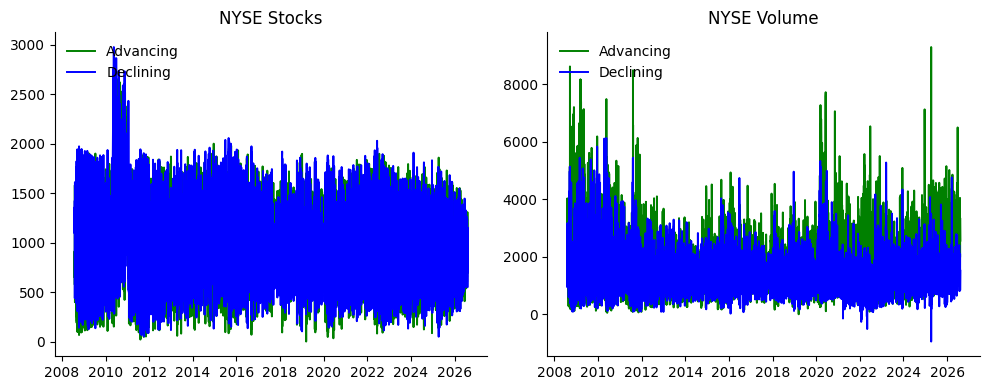

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(df.index, df["advancing_stocks"], color='green', linewidth=1.4, label="Advancing")
ax[0].plot(df.index, df["declining_stocks"], color='blue', linewidth=1.4, label="Declining")

ax[1].plot(df.index, df["advancing_volume"], color='green', linewidth=1.4, label="Advancing")
ax[1].plot(df.index, df["declining_volume"], color='blue', linewidth=1.4, label="Declining")

ax[0].set_title(f"{boerse} Stocks")
ax[0].legend(frameon=False, loc="upper left")
ax[0].spines[["top", "right"]].set_visible(False)

ax[1].set_title(f"{boerse} Volume")
ax[1].legend(frameon=False, loc="upper left")
ax[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

3. Ratio berechnen

In [11]:
df["volume_ratio"] = (df["advancing_volume"] / (df["advancing_volume"] + df["declining_volume"]))*100
df["stocks_ratio"] = (df["advancing_stocks"] / (df["advancing_stocks"] + df["declining_stocks"]))*100

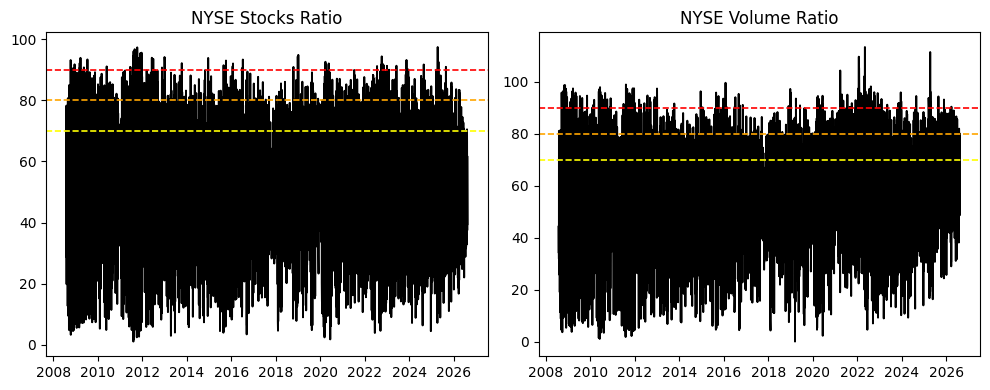

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(df.index, df["stocks_ratio"], color='black', linewidth=1.4, label="Ratio")
ax[0].axhline(90, color="red", linestyle="--", linewidth=1.2, label="90 %")
ax[0].axhline(80, color="orange", linestyle="--", linewidth=1.2, label="80 %")
ax[0].axhline(70, color="yellow", linestyle="--", linewidth=1.2, label="70 %")

ax[1].plot(df.index, df["volume_ratio"], color='black', linewidth=1.4, label="Ratio")
ax[1].axhline(90, color="red", linestyle="--", linewidth=1.2, label="90 %")
ax[1].axhline(80, color="orange", linestyle="--", linewidth=1.2, label="80 %")
ax[1].axhline(70, color="yellow", linestyle="--", linewidth=1.2, label="70 %")

ax[0].set_title(f"{boerse} Stocks Ratio")

ax[1].set_title(f"{boerse} Volume Ratio")

fig.tight_layout()
plt.show()

4. Untersuchen, was nach den Extremwerten passiert

In [13]:
HORIZONS = [30, 60, 90]

def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    '''Rendite von t bis t+horizon (in Handelstagen), bezogen auf Close.'''
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    '''Maximaler Drawdown ab dem laufenden Hoechststand innerhalb [t, t+horizon].

    Fuer jeden Zeitpunkt t wird das Fenster der naechsten `horizon` Handelstage
    betrachtet und der groesste prozentuale Rueckgang vom bis dahin erreichten
    Hoechststand innerhalb dieses Fensters berechnet (immer <= 0).
    '''
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        window = values[i : i + horizon + 1]
        running_max = np.maximum.accumulate(window)
        drawdowns = window / running_max - 1
        out[i] = drawdowns.min()
    return pd.Series(out, index=close.index)


# Zielgroessen fuer alle Horizonte berechnen und an df anhaengen
for h in HORIZONS:
    raw[f"fwd_return_{h}d"] = forward_return(raw["Close"], h)
    raw[f"fwd_mdd_{h}d"] = forward_max_drawdown(raw["Close"], h)

print("Zielgroessen berechnet fuer Horizonte:", HORIZONS)
raw.filter(like="fwd_").describe()

Zielgroessen berechnet fuer Horizonte: [30, 60, 90]


,fwd_return_30d,fwd_mdd_30d,fwd_return_60d,fwd_mdd_60d,fwd_return_90d,fwd_mdd_90d
count,4902.000000,4902.000000,4872.000000,4872.000000,4842.000000,4842.000000
mean,0.016781,-0.060992,0.033965,-0.089038,0.050858,-0.109711
std,0.066819,0.048381,0.092804,0.064750,0.113113,0.074874
min,-0.316021,-0.337746,-0.447579,-0.454263,-0.423980,-0.463612
25%,-0.017267,-0.078302,-0.011015,-0.109247,-0.002921,-0.131473
50%,0.024523,-0.045748,0.044904,-0.072976,0.063689,-0.087038
75%,0.056475,-0.028610,0.085877,-0.043207,0.115581,-0.057987
max,0.295758,-0.007704,0.451259,-0.014042,0.543262,-0.018665


In [14]:
# Füge die Rendite und den Max Drawdown zum allgemeinen df hinzu
raw.index = pd.to_datetime(raw.index)

df = df.join(raw[["fwd_return_30d", "fwd_mdd_30d", "fwd_return_60d", "fwd_mdd_60d", "fwd_return_90d", "fwd_mdd_90d"]],how = "left")

print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 4524 entries, 2008-07-31 to 2026-08-10
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   advancing_stocks  4524 non-null   int64  
 1   advancing_volume  4524 non-null   float64
 2   declining_stocks  4523 non-null   float64
 3   declining_volume  4524 non-null   float64
 4   volume_ratio      4524 non-null   float64
 5   stocks_ratio      4523 non-null   float64
 6   fwd_return_30d    4495 non-null   float64
 7   fwd_mdd_30d       4495 non-null   float64
 8   fwd_return_60d    4465 non-null   float64
 9   fwd_mdd_60d       4465 non-null   float64
 10  fwd_return_90d    4435 non-null   float64
 11  fwd_mdd_90d       4435 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 459.5 KB
None


In [15]:
# Aufteilung in verschiedene Regime (über 90%, 80%, 70%)
stock_over_90 = df[df["stocks_ratio"] >= 90]
print("Stock über 90%:")
print(stock_over_90[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
stock_over_80 = df[df["stocks_ratio"] >= 80]
print("Stock über 80%:")
print(stock_over_80[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
stock_over_70 = df[df["stocks_ratio"] >= 70]
print("Stock über 70%:")
print(stock_over_70[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()

volume_over_90 = df[df["volume_ratio"] >= 90]
print("Volumen über 90%:")
print(volume_over_90[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
volume_over_80 = df[df["volume_ratio"] >= 80]
print("Volumen über 80%:")
print(volume_over_80[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
volume_over_70 = df[df["volume_ratio"] >= 70]
print("Volumen über 70%:")
print(volume_over_70[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())

Stock über 90%:
       volume_ratio  stocks_ratio  fwd_return_30d  fwd_mdd_30d
count     59.000000     59.000000       59.000000    59.000000
mean      93.437107     92.660823        0.044704    -0.064110
std        4.669764      1.848261        0.072214     0.042586
min       82.557286     90.046899       -0.201833    -0.286366
25%       91.033369     91.130436        0.004799    -0.083500
50%       94.435762     92.123288        0.034473    -0.053686
75%       96.239776     93.831429        0.085379    -0.038645
max      111.362677     97.383569        0.211915    -0.008964

Stock über 80%:
       volume_ratio  stocks_ratio  fwd_return_30d  fwd_mdd_30d
count    448.000000    448.000000      448.000000   448.000000
mean      87.311480     85.393162        0.022363    -0.066222
std        6.439822      3.884054        0.074182     0.053987
min       62.891530     80.021086       -0.316021    -0.337746
25%       83.540995     82.221518       -0.015177    -0.083219
50%       87.789070   

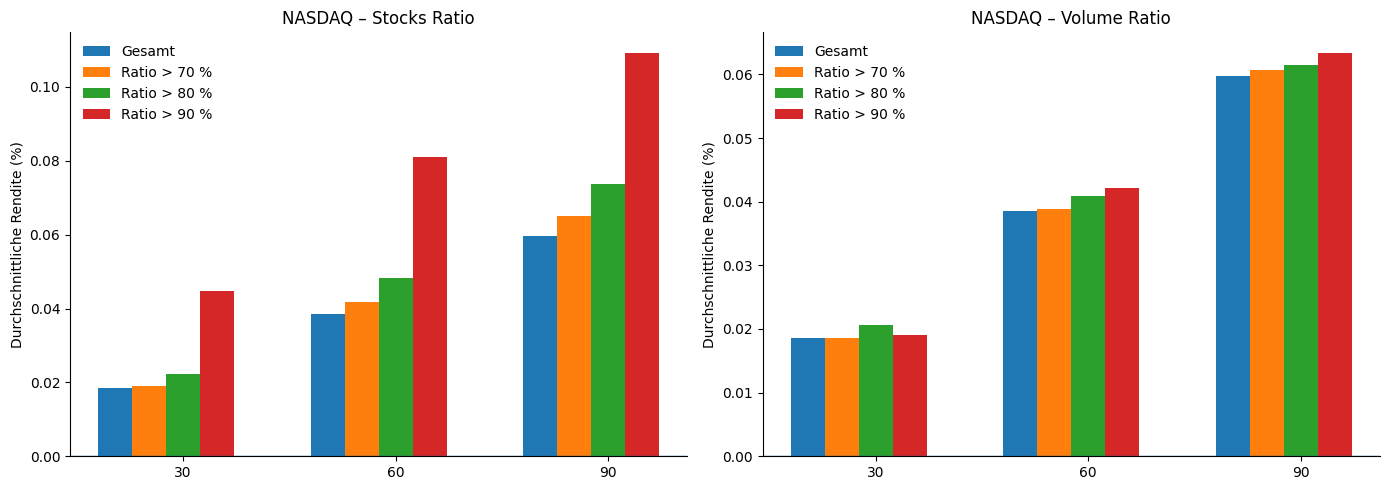

In [16]:
x = np.arange(len(HORIZONS)) + 1
width = 0.16

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Stocks Ratio
# -------------------------

ax[0].bar(x - 2*width, df[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Gesamt")
ax[0].bar(x - width, stock_over_70[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[0].bar(x,         stock_over_80[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[0].bar(x + width, stock_over_90[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[0].axhline(0, linewidth=1)

ax[0].set_xticks(x)
ax[0].set_xticklabels(HORIZONS)

ax[0].set_ylabel("Durchschnittliche Rendite (%)")
ax[0].set_title("NASDAQ – Stocks Ratio")
ax[0].legend(frameon=False)

ax[0].spines[["top", "right"]].set_visible(False)


# -------------------------
# Volume Ratio
# -------------------------

ax[1].bar(x - 2*width, df[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Gesamt")
ax[1].bar(x - width, volume_over_70[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[1].bar(x,         volume_over_80[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[1].bar(x + width, volume_over_90[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[1].axhline(0, linewidth=1)

ax[1].set_xticks(x)
ax[1].set_xticklabels(HORIZONS)

ax[1].set_ylabel("Durchschnittliche Rendite (%)")
ax[1].set_title("NASDAQ – Volume Ratio")
ax[1].legend(frameon=False)

ax[1].spines[["top", "right"]].set_visible(False)


fig.tight_layout()
plt.show()

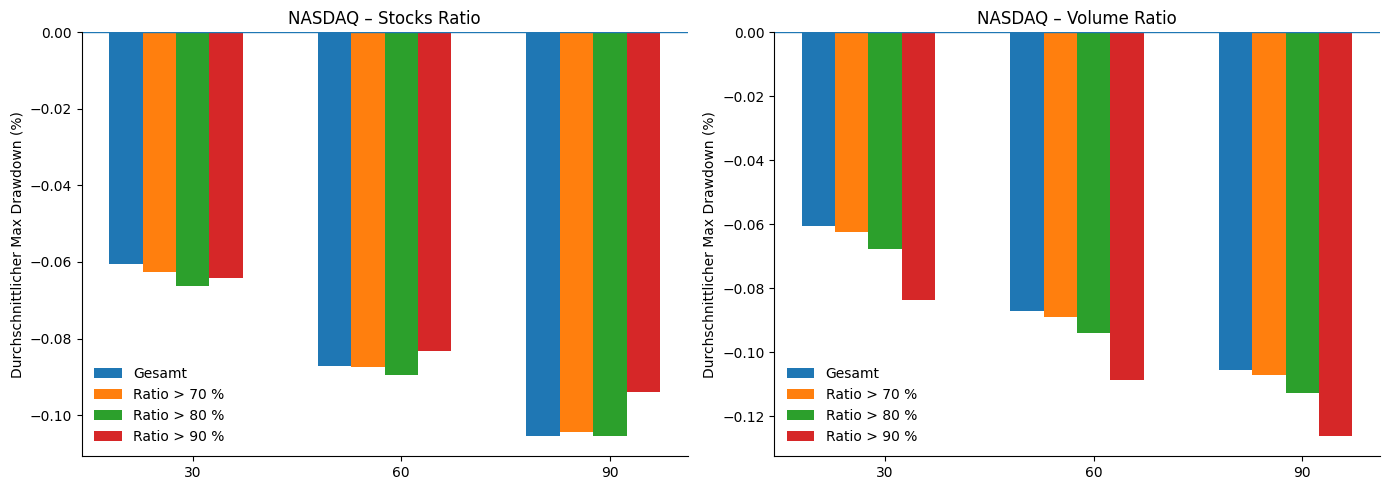

In [17]:
x = np.arange(len(HORIZONS))
width = 0.16

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Stocks Ratio
# -------------------------

ax[0].bar(x - 2*width, df[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Gesamt")
ax[0].bar(x - width, stock_over_70[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[0].bar(x,         stock_over_80[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[0].bar(x + width, stock_over_90[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[0].axhline(0, linewidth=1)

ax[0].set_xticks(x)
ax[0].set_xticklabels(HORIZONS)

ax[0].set_ylabel("Durchschnittlicher Max Drawdown (%)")
ax[0].set_title("NASDAQ – Stocks Ratio")
ax[0].legend(frameon=False)

ax[0].spines[["top", "right"]].set_visible(False)


# -------------------------
# Volume Ratio
# -------------------------

ax[1].bar(x - 2*width, df[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Gesamt")
ax[1].bar(x - width, volume_over_70[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[1].bar(x,         volume_over_80[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[1].bar(x + width, volume_over_90[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[1].axhline(0, linewidth=1)

ax[1].set_xticks(x)
ax[1].set_xticklabels(HORIZONS)

ax[1].set_ylabel("Durchschnittlicher Max Drawdown (%)")
ax[1].set_title("NASDAQ – Volume Ratio")
ax[1].legend(frameon=False)

ax[1].spines[["top", "right"]].set_visible(False)


fig.tight_layout()
plt.show()